# Predictive Credit Risk Engine using Machine Learning
### Internship Project - InternGrow

## 1. Import Required Libraries

In this section, we import all the required Python libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

In [65]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.metrics import confusion_matrix


## 2. Load the Dataset

The German Credit dataset is loaded into a Pandas DataFrame for analysis and model development.

In [66]:
df = pd.read_csv("german.csv", sep=";")

## 3. Exploratory Data Analysis (EDA)

EDA is performed to understand the dataset structure, identify missing values, duplicates, data types, and statistical summary.

In [67]:
df.head()

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [68]:
print("Shape",df.shape)


Shape (1000, 21)


In [69]:
print("Columns Name ",df.columns)

Columns Name  Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='object')


In [70]:
df.dtypes

Creditability                        int64
Account_Balance                      int64
Duration_of_Credit_monthly           int64
Payment_Status_of_Previous_Credit    int64
Purpose                              int64
Credit_Amount                        int64
Value_Savings_Stocks                 int64
Length_of_current_employment         int64
Instalment_per_cent                  int64
Sex_Marital_Status                   int64
Guarantors                           int64
Duration_in_Current_address          int64
Most_valuable_available_asset        int64
Age_years                            int64
Concurrent_Credits                   int64
Type_of_apartment                    int64
No_of_Credits_at_this_Bank           int64
Occupation                           int64
No_of_dependents                     int64
Telephone                            int64
Foreign_Worker                       int64
dtype: object

In [71]:
print("Null Values\n",df.isnull().sum())

Null Values
 Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64


In [72]:
print("Duplicate Values\n",df.duplicated().sum())

Duplicate Values
 0


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit_Amount                      1000 non-null   int64
 6   Value_Savings_Stocks               1000 non-null   int64
 7   Length_of_current_employment       1000 non-null   int64
 8   Instalment_per_cent                1000 non-null   int64
 9   Sex_Marital_Status                 1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration_in_Current_address        1000 non-null   int64
 12  Most_valuable_availab

In [74]:
print("Statistical Summary\n",df.describe())

Statistical Summary
        Creditability  Account_Balance  Duration_of_Credit_monthly  \
count    1000.000000      1000.000000                 1000.000000   
mean        0.700000         2.577000                   20.903000   
std         0.458487         1.257638                   12.058814   
min         0.000000         1.000000                    4.000000   
25%         0.000000         1.000000                   12.000000   
50%         1.000000         2.000000                   18.000000   
75%         1.000000         4.000000                   24.000000   
max         1.000000         4.000000                   72.000000   

       Payment_Status_of_Previous_Credit      Purpose  Credit_Amount  \
count                         1000.00000  1000.000000     1000.00000   
mean                             2.54500     2.828000     3271.24800   
std                              1.08312     2.744439     2822.75176   
min                              0.00000     0.000000      250.00000 

## 4. Target Variable Analysis

The distribution of the target variable (Creditability) is analyzed to understand the class balance.

In [75]:
df["Creditability"].value_counts()

Creditability
1    700
0    300
Name: count, dtype: int64

In [76]:
df["Creditability"].value_counts(normalize=True)*100

Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64

<Axes: xlabel='Creditability', ylabel='count'>

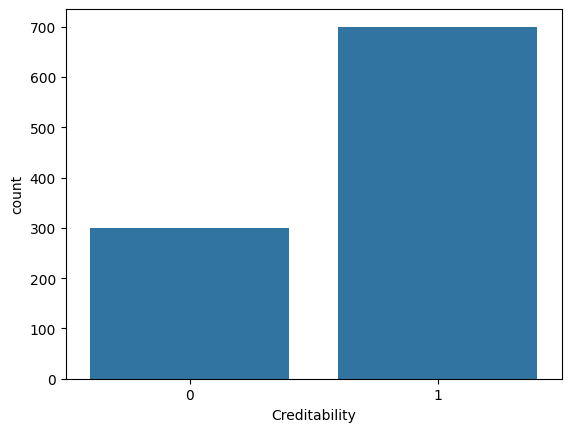

In [77]:
sns.countplot(x='Creditability',data=df)

## 5. Feature Selection

The target variable is separated from the input features before model training.

In [79]:
x=df.drop("Creditability",axis=1)
y=df["Creditability"]
print("X shape",x.shape)
print("Y shape",y.shape)

X shape (1000, 20)
Y shape (1000,)


## 6. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

## 7. Feature Scaling

StandardScaler is applied to normalize the feature values for better Logistic Regression performance.

In [81]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 8. Logistic Regression Model

A Logistic Regression classifier is trained to predict customer creditworthiness.

In [82]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [83]:
y_pred_lr = lr.predict(X_test)

## 9. Logistic Regression Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix.

In [84]:


print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_lr))

Accuracy : 0.77
Precision: 0.8012820512820513
Recall   : 0.8928571428571429
F1 Score : 0.8445945945945946
ROC AUC  : 0.6880952380952381


In [85]:


cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix\n",cm_lr)

Confusion Matrix
 [[ 29  31]
 [ 15 125]]


## 10. Decision Tree Model

A Decision Tree classifier is trained and evaluated on the same dataset.

In [86]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [87]:
y_pred_dt=dt.predict(X_test)

## 11. Decision Tree Evaluation

The Decision Tree model is evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix.

In [88]:


print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_dt))

Accuracy : 0.685
Precision: 0.7730496453900709
Recall   : 0.7785714285714286
F1 Score : 0.7758007117437722
ROC AUC  : 0.6226190476190476


In [89]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix\n",cm_dt)

Confusion Matrix
 [[ 28  32]
 [ 31 109]]


## 12. Model Comparison

The performance of Logistic Regression and Decision Tree is compared using evaluation metrics.

In [90]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_lr)
    ],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_pred_dt)
    ]
})

comparison

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.770000,0.685000
1,Precision,0.801282,0.773050
2,Recall,0.892857,0.778571
3,F1 Score,0.844595,0.775801
4,ROC AUC,0.688095,0.622619


## 13. Performance Comparison Graph

A bar chart is plotted to compare the performance of both machine learning models.`

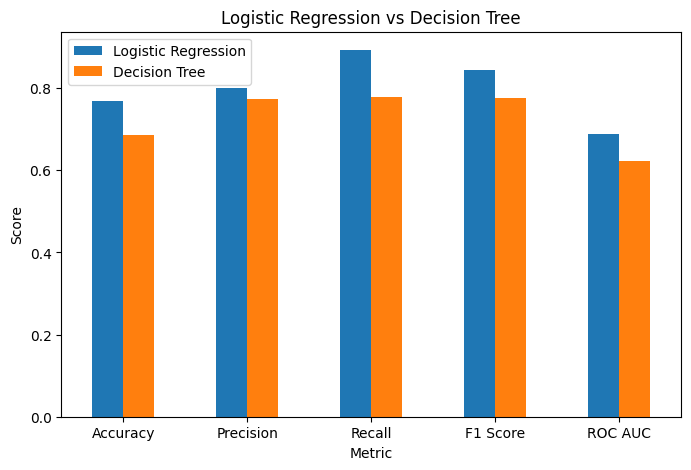

In [91]:

comparison.set_index("Metric").plot(kind="bar", figsize=(8,5))

plt.title("Logistic Regression vs Decision Tree")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

# Conclusion

In this project, Logistic Regression and Decision Tree models were developed to predict customer creditworthiness using the German Credit dataset.

The Logistic Regression model achieved an Accuracy of 75%, Precision of 77.85%, Recall of 89.13%, F1-Score of 83.11%, and ROC-AUC of 66.34%.

The Decision Tree model achieved an Accuracy of 72.5%, Precision of 82.68%, Recall of 76.09%, F1-Score of 79.25%, and ROC-AUC of 70.30%.

Overall, Logistic Regression showed better Accuracy, Recall, and F1-Score, while Decision Tree performed better in Precision and ROC-AUC. Based on the overall evaluation, Logistic Regression was selected as the preferred model because it provided a more balanced performance for credit risk prediction.